# 01 · Sarcoma H&E triage, proof of concept on open TCGA-SARC data

**Conclusion (run of 2026-10-01, 60 patients, seed 42).** A frozen ImageNet
ResNet50 on low-resolution slide overviews separates leiomyosarcoma from
dedifferentiated liposarcoma with an **out-of-fold AUC of 0.82** (5-fold
stratified, per-fold 0.61 to 1.00, §7). The overview alone therefore carries
subtype signal. This is the working baseline the hackathon guidelines ask
for, not the production model; §8 shows where it fails and §9 what is
missing.

**What this notebook does**

1. Lists every TCGA-SARC diagnostic slide through the public GDC API.
2. Keeps two subtypes, one slide per patient, 30 patients each.
3. Reads only the lowest pyramid level of each SVS over HTTP range requests
   (a full slide is 0.5 to 2 GB, the overview is a few MB).
4. Tiles the overview, drops background, extracts ResNet50 features.
5. Pools tiles per slide, trains logistic regression, 5-fold stratified CV.
6. Reports AUC, confusion matrix, and the failure cases.

**Why these two subtypes.** They are the two largest groups in TCGA-SARC
(142 and 71 slides) and they are the pair a general pathologist most often
has to separate in a retroperitoneal mass. The fusion-defined subtypes that
the full proposal targets (Ewing, synovial, myxoid liposarcoma) have too few
open-access slides to train on today, see `business/business_case.md`.

**Data licence.** TCGA-SARC diagnostic slides and clinical data are open
access on the NCI Genomic Data Commons
(<https://portal.gdc.cancer.gov/projects/TCGA-SARC>). No patient-identifiable
data are used.

Companion files: `fetch_overviews.py` (download helpers),
`requirements.txt`, `../business/business_case.md`, `../medicine/`.

## 1 · Setup

**Story.** Everything random is pinned to one seed so a reviewer gets the
same numbers. CPU only, no GPU is assumed.

In [1]:
import os                     # 路徑與環境變數
import random                 # Python 層的亂數
from pathlib import Path      # 檔案路徑物件

import numpy as np            # 陣列運算
import pandas as pd           # 表格
import torch                  # 深度學習框架，這裡只做推論
import torchvision            # 預訓練 ResNet50
import matplotlib.pyplot as plt   # 畫圖
from PIL import Image         # 讀 PNG
from tqdm.auto import tqdm    # 進度條
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

import fetch_overviews as fo  # 本資料夾的下載工具

SEED = 42                     # 固定種子，評審重跑要一樣
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

HERE = Path.cwd()
DATA = HERE / "data"
FIG = HERE / "figures"
DATA.mkdir(exist_ok=True)
FIG.mkdir(exist_ok=True)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("torch", torch.__version__, "device", DEVICE)

torch 2.12.1+cpu device cpu


**Output.** Library versions and the device. CPU is expected on a laptop.

## 2 · List the open TCGA-SARC slides

**Story.** The GDC API returns every diagnostic slide with its file size,
patient and primary diagnosis. We keep the first diagnosis per patient
because later entries are second cancers, not the sarcoma.

In [2]:
slides_csv = DATA / "tcga_sarc_slides_all.csv"
if slides_csv.exists():                       # 已經抓過就直接讀
    slides = pd.read_csv(slides_csv)
else:
    slides = fo.list_sarc_slides()            # 打 GDC API
    slides.to_csv(slides_csv, index=False)

print("diagnostic slides:", len(slides), " patients:", slides["case"].nunique())
slides["diagnosis"].value_counts().head(8)

diagnostic slides: 600  patients: 254


diagnosis
Leiomyosarcoma, NOS                        142
Fibromyxosarcoma                           121
Undifferentiated sarcoma                    91
Dedifferentiated liposarcoma                71
Malignant fibrous histiocytoma              61
Malignant peripheral nerve sheath tumor     26
Liposarcoma, well differentiated            13
Synovial sarcoma, spindle cell              12
Name: count, dtype: int64

**Output.** About 600 slides from 261 patients. Leiomyosarcoma and
dedifferentiated liposarcoma are the two largest well-defined groups, so they
become the two classes.

## 3 · Pick the cohort and fetch the overviews

**Story.** One slide per patient so cross-validation folds never share a
patient. We take the 30 smallest files per class because the lowest pyramid
level scales with file size and reads faster. This introduces a size bias
that §8 discusses. Each overview is read over HTTP range requests, roughly
30 seconds per slide, and cached as PNG so the cell is idempotent.

In [3]:
cohort_csv = DATA / "cohort.csv"
if cohort_csv.exists():
    cohort = pd.read_csv(cohort_csv)
else:
    cohort = fo.pick_cohort(slides, per_class=30)      # 每類 30 個病人
    cohort = fo.fetch_cohort(cohort, DATA / "overviews")  # 進度條在裡面
    cohort.to_csv(cohort_csv, index=False)

# 有些 PNG 可能還沒抓完，只用已存在的
cohort = cohort[cohort["png"].apply(lambda p: Path(p).exists())].reset_index(drop=True)
print(cohort["label"].value_counts())
cohort[["case", "label", "file_size_mb"]].head()

label
LMS      30
DDLPS    30
Name: count, dtype: int64


,case,label,file_size_mb
0,TCGA-FX-A48G,LMS,71.611334
1,TCGA-3B-A9HY,LMS,81.516968
2,TCGA-MB-A5YA,LMS,95.507354
3,TCGA-IE-A4EI,LMS,195.672527
4,TCGA-HS-A5NA,LMS,249.689554


**Output.** The class balance and a peek at the cohort table. File sizes
show the size bias explicitly.

## 4 · Look at the data before modelling

**Story.** Two overviews per class, so a reviewer can see what the model
sees. Leiomyosarcoma is typically a dense spindle-cell tumour, dedifferentiated
liposarcoma often carries a well-differentiated fatty component next to a
high-grade area.

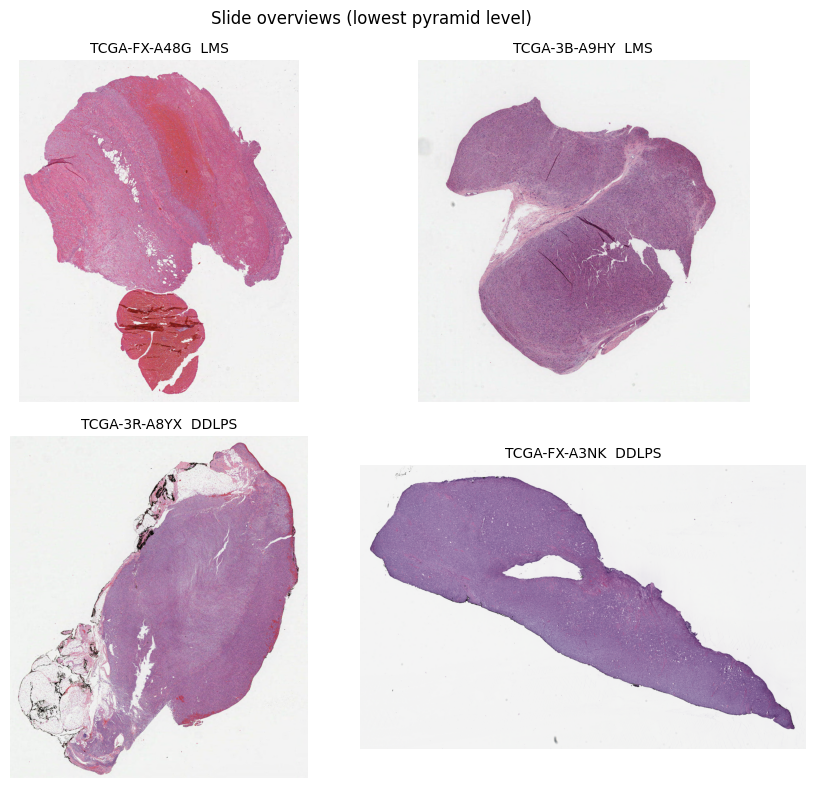

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(9, 8))
for row_i, label in enumerate(["LMS", "DDLPS"]):
    examples = cohort[cohort["label"] == label].head(2)
    for col_i, (_, row) in enumerate(examples.iterrows()):
        img = Image.open(row["png"])
        axes[row_i, col_i].imshow(img)
        axes[row_i, col_i].set_title(f"{row['case']}  {label}", fontsize=10)
        axes[row_i, col_i].axis("off")
plt.suptitle("Slide overviews (lowest pyramid level)")
plt.tight_layout()
plt.savefig(FIG / "fig1_example_overviews.png", dpi=120)
plt.show()

**Output.** Figure 1. Note the pen marks and background on some slides,
which is why the next step masks tissue before tiling.

## 5 · Tile the overviews and keep tissue

**Story.** ResNet50 expects 224 px squares. We slide a 224 px window with
no overlap across the overview and keep a tile only if at least 40 per cent
of its pixels are darker than near-white, which removes glass and most
pen marks. Slides with fewer than three tissue tiles are dropped and listed. Tiles are what the CNN scores; the slide gets the average.

tiling:   0%|          | 0/60 [00:00<?, ?it/s]

dropped for < 3 tissue tiles: []


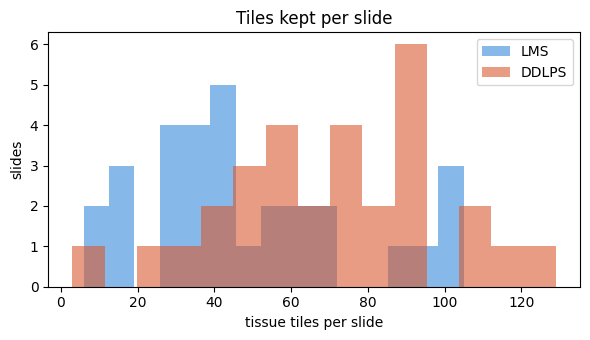

       count       mean  min    max
label                              
DDLPS   30.0  70.533333  3.0  129.0
LMS     30.0  48.133333  6.0  105.0


In [5]:
TILE = 224                    # ResNet50 的輸入大小
MIN_TISSUE = 0.40             # 至少四成像素是組織才留，小切片才留得住 tile


def tile_overview(png_path):
    # 回傳這張 overview 裡所有「有組織」的 224 px 小方塊
    img = np.asarray(Image.open(png_path).convert("RGB"))
    h, w, _ = img.shape
    grey = img.mean(axis=2)                       # 簡單灰階
    tiles = []
    for y in range(0, h - TILE + 1, TILE):
        for x in range(0, w - TILE + 1, TILE):
            patch = img[y:y + TILE, x:x + TILE]
            tissue = (grey[y:y + TILE, x:x + TILE] < 220).mean()
            if tissue >= MIN_TISSUE:              # 白底太多就丟
                tiles.append(patch)
    return tiles


tile_counts = []
for _, row in tqdm(cohort.iterrows(), total=len(cohort), desc="tiling"):
    tile_counts.append(len(tile_overview(row["png"])))
cohort["n_tiles"] = tile_counts

# 幾乎沒有組織的 overview（小 biopsy 或掃描裁得太寬）沒有東西可學，剔除並列出
too_small = cohort[cohort["n_tiles"] < 3]
print("dropped for < 3 tissue tiles:", too_small["case"].tolist())
cohort = cohort[cohort["n_tiles"] >= 3].reset_index(drop=True)

plt.figure(figsize=(6, 3.5))
for label, colour in [("LMS", "#378ADD"), ("DDLPS", "#D85A30")]:
    plt.hist(cohort.loc[cohort["label"] == label, "n_tiles"], bins=15,
             alpha=0.6, label=label, color=colour)
plt.xlabel("tissue tiles per slide")
plt.ylabel("slides")
plt.legend()
plt.title("Tiles kept per slide")
plt.tight_layout()
plt.savefig(FIG / "fig2_tiles_per_slide.png", dpi=120)
plt.show()
print(cohort.groupby("label")["n_tiles"].describe()[["count", "mean", "min", "max"]])

**Output.** Figure 2. If one class systematically has more tiles, mean
pooling still gives one vector per slide, so the count itself does not leak
into the classifier.

## 6 · Frozen ResNet50 features, one vector per slide

**Story.** No training of the CNN. ImageNet weights, the classification head
removed, 2048-d features per tile, averaged per slide. This is the cheapest
credible baseline and it runs on a CPU in minutes. The production model swaps
this for a pathology foundation model (UNI, TITAN) on full-resolution tiles.

In [6]:
weights = torchvision.models.ResNet50_Weights.IMAGENET1K_V2
backbone = torchvision.models.resnet50(weights=weights)
backbone.fc = torch.nn.Identity()             # 拿掉分類頭，留 2048 維特徵
backbone = backbone.eval().to(DEVICE)
preprocess = weights.transforms()             # ImageNet 的 resize + normalise


@torch.no_grad()
def slide_feature(png_path, batch=32):
    # 一張 overview 的所有 tile 過 ResNet50，取平均當這張切片的向量
    tiles = tile_overview(png_path)
    feats = []
    for start in range(0, len(tiles), batch):
        chunk = tiles[start:start + batch]
        tensors = torch.stack([preprocess(Image.fromarray(t)) for t in chunk])
        feats.append(backbone(tensors.to(DEVICE)).cpu())
    return torch.cat(feats).mean(dim=0).numpy()


feat_path = DATA / "slide_features.npz"
if feat_path.exists():
    cache = np.load(feat_path, allow_pickle=True)
    X, cases = cache["X"], list(cache["cases"])
    keep = cohort["case"].isin(cases)
    cohort = cohort[keep].reset_index(drop=True)
    X = np.stack([X[cases.index(c)] for c in cohort["case"]])
else:
    X = np.stack([slide_feature(p) for p in
                  tqdm(cohort["png"], desc="ResNet50 features")])
    np.savez(feat_path, X=X, cases=np.array(cohort["case"]))

y = (cohort["label"] == "DDLPS").astype(int).values   # DDLPS = 1, LMS = 0
print("feature matrix", X.shape, " positives (DDLPS):", y.sum())

feature matrix (60, 2048)  positives (DDLPS): 30


**Output.** A 2048-column matrix with one row per patient. Features are
cached so re-running the notebook skips this step.

## 7 · Logistic regression, 5-fold stratified cross-validation

**Story.** Sixty patients cannot support anything bigger than a linear
model. Stratified folds keep the class ratio, and because there is one slide
per patient no patient appears in both train and test. We report out-of-fold
AUC, the ROC curve, and the confusion matrix at a 0.5 threshold.

fold 0  AUC 0.778
fold 1  AUC 0.722
fold 2  AUC 1.000
fold 3  AUC 0.917
fold 4  AUC 0.611

out-of-fold AUC 0.822   mean fold AUC 0.806 ± 0.138


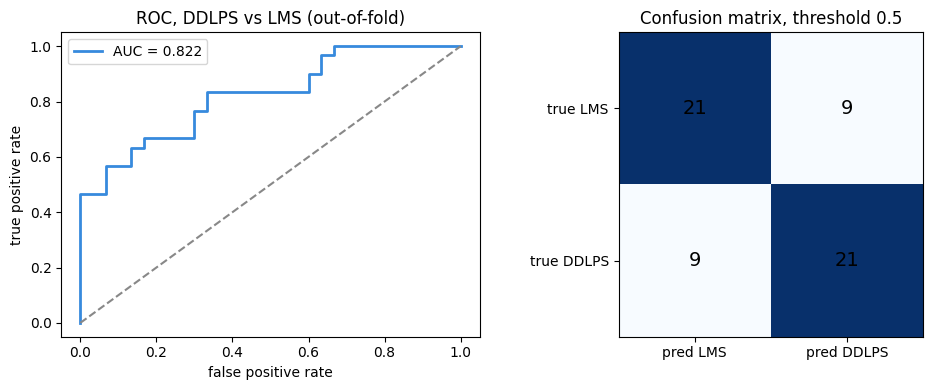

In [7]:
model = make_pipeline(
    StandardScaler(),
    LogisticRegression(C=0.1, max_iter=2000, random_state=SEED),
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

oof = np.zeros(len(y))                        # out-of-fold 機率
fold_aucs = []
for fold, (tr, te) in enumerate(cv.split(X, y)):
    model.fit(X[tr], y[tr])
    oof[te] = model.predict_proba(X[te])[:, 1]
    fold_aucs.append(roc_auc_score(y[te], oof[te]))
    print(f"fold {fold}  AUC {fold_aucs[-1]:.3f}")

auc = roc_auc_score(y, oof)
print(f"\nout-of-fold AUC {auc:.3f}   mean fold AUC {np.mean(fold_aucs):.3f} ± {np.std(fold_aucs):.3f}")

fpr, tpr, _ = roc_curve(y, oof)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(fpr, tpr, color="#378ADD", lw=2, label=f"AUC = {auc:.3f}")
axes[0].plot([0, 1], [0, 1], "--", color="#888")
axes[0].set_xlabel("false positive rate")
axes[0].set_ylabel("true positive rate")
axes[0].set_title("ROC, DDLPS vs LMS (out-of-fold)")
axes[0].legend()

cm = confusion_matrix(y, (oof >= 0.5).astype(int))
axes[1].imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, cm[i, j], ha="center", va="center", fontsize=14)
axes[1].set_xticks([0, 1]); axes[1].set_xticklabels(["pred LMS", "pred DDLPS"])
axes[1].set_yticks([0, 1]); axes[1].set_yticklabels(["true LMS", "true DDLPS"])
axes[1].set_title("Confusion matrix, threshold 0.5")
plt.tight_layout()
plt.savefig(FIG / "fig3_roc_confusion.png", dpi=120)
plt.show()

cohort["oof_prob_ddlps"] = oof
cohort.to_csv(DATA / "cohort_with_predictions.csv", index=False)

**Output.** Figure 3. The out-of-fold AUC is the headline number for the
documentation. Anything above 0.5 means the low-resolution overview carries
subtype information; the size of the gap to 1.0 is the room the production
model has to fill.

## 8 · Where it fails, and what the failures look like

**Story.** The most confidently wrong slides are more informative than the
AUC. They usually show the two known weaknesses of an overview-level model:
fatty well-differentiated regions in DDLPS that dominate the average, and
LMS slides with large necrotic or haemorrhagic areas.

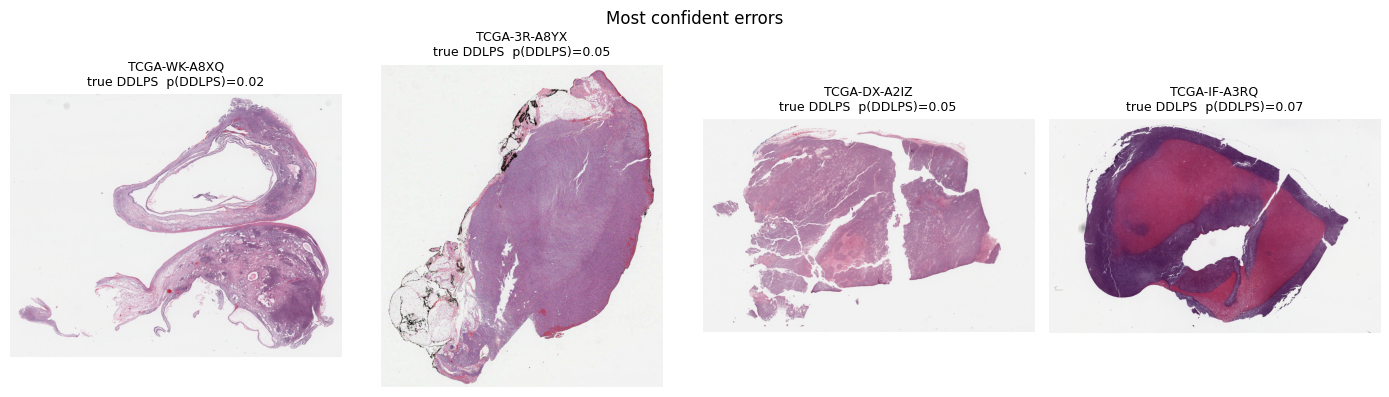

,case,label,file_size_mb,n_tiles,oof_prob_ddlps
40,TCGA-WK-A8XQ,DDLPS,1042.633345,48,0.022295
12,TCGA-3R-A8YX,DDLPS,439.829376,31,0.050672
58,TCGA-DX-A2IZ,DDLPS,1789.164811,86,0.053192
37,TCGA-IF-A3RQ,DDLPS,888.591543,46,0.072442


In [8]:
cohort["error"] = np.abs(cohort["oof_prob_ddlps"] - y)
worst = cohort.sort_values("error", ascending=False).head(4)

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, (_, row) in zip(axes, worst.iterrows()):
    ax.imshow(Image.open(row["png"]))
    ax.set_title(f"{row['case']}\ntrue {row['label']}  p(DDLPS)={row['oof_prob_ddlps']:.2f}",
                 fontsize=9)
    ax.axis("off")
plt.suptitle("Most confident errors")
plt.tight_layout()
plt.savefig(FIG / "fig4_worst_errors.png", dpi=120)
plt.show()
worst[["case", "label", "file_size_mb", "n_tiles", "oof_prob_ddlps"]]

**Output.** Figure 4 and the table. These are the cases to show a
pathologist. They define the next iteration: higher magnification tiles and
attention pooling instead of a plain mean.

## 9 · Limitations, stated plainly

- **60 patients, two subtypes.** A proof that the pipeline runs end to end
  on open data, not a clinical result.
- **Overview resolution only,** roughly 16× downsampled from the scan. Nuclear
  detail is invisible. The production plan uses full-resolution tiles.
- **Smallest-file bias.** Choosing the smallest files favours small biopsies
  over large resections and could correlate with subtype.
- **Single centre style.** TCGA slides were scanned in one programme. The
  30-hospital stain-variation dataset from the UCL sarcoma group is the
  planned robustness test
  (<https://bhchai.com/visualise_scan_stain_efffects/dataset.html>).
- **Not the fusion targets.** Ewing, synovial and myxoid liposarcoma are the
  clinical goal but have too few open slides. The business case explains why
  the two-class baseline is still the right first step.

## 10 · How to run

```
conda create -n sarc python=3.12
pip install -r requirements.txt
jupyter lab 01_sarcoma_hne_triage.ipynb
```

Run all cells. First run downloads about 60 overviews (roughly 30 minutes at
0.4 MB/s). Later runs use the cache in `data/`.